In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import joblib

In [12]:
df = pd.read_csv('deceptive-opinion.csv')

In [13]:
df

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...
...,...,...,...,...,...
1595,deceptive,intercontinental,negative,MTurk,Problems started when I booked the InterContin...
1596,deceptive,amalfi,negative,MTurk,The Amalfi Hotel has a beautiful website and i...
1597,deceptive,intercontinental,negative,MTurk,The Intercontinental Chicago Magnificent Mile ...
1598,deceptive,palmer,negative,MTurk,"The Palmer House Hilton, while it looks good i..."


In [14]:
df['target'] = df['deceptive'].map({'deceptive': 1, 'truthful': 0})

In [15]:
x = df['text']
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [18]:
predictions = rf.predict(x_test_tfidf)
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       168
           1       0.79      0.90      0.84       152

    accuracy                           0.84       320
   macro avg       0.84      0.84      0.84       320
weighted avg       0.85      0.84      0.84       320

Accuracy: 0.840625


Confusion Matrix:
[[132  36]
 [ 15 137]]


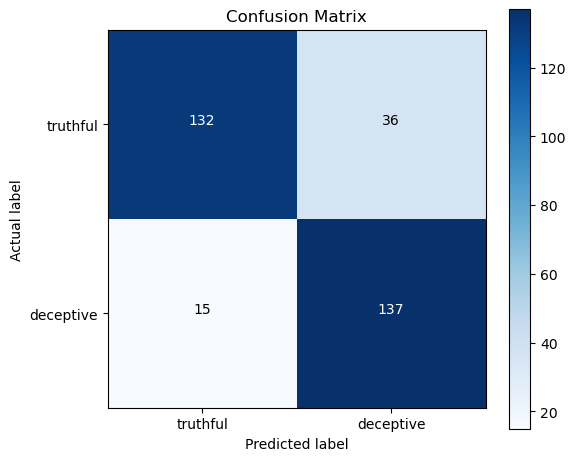

In [19]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
class_names = ['truthful', 'deceptive']
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(vectorizer, 'rf_tfidf_vectorizer.pkl')

['rf_tfidf_vectorizer.pkl']